# Shea Homes Customer Review Analysis
### Notebook: `05_predictive_models`

> Run `01_setup_and_summary_stats.ipynb` first, or execute the setup cell below.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

# keep apostrophes so contractions like "don't" stay as one token
TOKEN_PATTERN = r"(?u)\b\w[\w']+\b"

In [3]:
# load the dataset
df = pd.read_csv("../shea_homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# derived columns
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M")
df["quarter"] = df["date"].dt.to_period("Q")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,052 reviews
Date range: September 2020 to April 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness,word_count,char_count,state,year,year_month,quarter
0,Good overall,Constance G.,Yes,2026-04-01,"OCALA, FL",A little overwhelming for me as a single elder...,5,5,5,5,5,86,434,FL,2026,2026-04,2026Q2
1,"Excellent, knowledgeable and responsive",Emily V.,Yes,2026-03-31,"Littleton, CO",Our experience exceeded our expectations. The ...,5,5,5,5,5,32,218,CO,2026,2026-03,2026Q1
2,Overall great experience!,Lynn S.,Yes,2026-03-26,"Kuna, ID",This is our second Shea home! Our whole proces...,5,5,5,5,5,83,516,ID,2026,2026-03,2026Q1


In [4]:
# ── Prerequisites: compute sentiment columns ──
# (These are normally created in notebook 03_sentiment_analysis)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
scores = df["review_text"].apply(lambda x: sia.polarity_scores(str(x)))
df["vader_compound"] = scores.apply(lambda x: x["compound"])
df["vader_pos"] = scores.apply(lambda x: x["pos"])
df["vader_neg"] = scores.apply(lambda x: x["neg"])
df["vader_neu"] = scores.apply(lambda x: x["neu"])
df["vader_label"] = df["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral"))
df["textblob_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["textblob_label"] = df["textblob_polarity"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral"))

# stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["home","shea","homes","new","would","one","us","also","get","got",
    "even","like","really","much","could","said","told","went","going","still",
    "back","made","make","well","since","every"])
print(f"Sentiment columns ready. {len(df)} reviews, VADER pos/neg/neu computed.")


Sentiment columns ready. 2052 reviews, VADER pos/neg/neu computed.


In [5]:
# ── Prerequisites: feature engineering for ML ──
# (These are normally created earlier in notebook 05)
from scipy.sparse import hstack, csr_matrix

df["exclamation_count"] = df["review_text"].apply(lambda x: str(x).count("!"))
extra_features = ["vader_compound", "word_count", "exclamation_count"]

def build_hybrid_features(X_texts, X_extras, tfidf_model, fit=False):
    if fit:
        text_features = tfidf_model.fit_transform(X_texts)
    else:
        text_features = tfidf_model.transform(X_texts)
    numeric_features = csr_matrix(X_extras.values)
    return hstack([text_features, numeric_features])

print(f"ML features ready: {extra_features}")


ML features ready: ['vader_compound', 'word_count', 'exclamation_count']


---
# 5 Predictive AI: Can We Predict Star Ratings From Text?

### The Big Question
If a customer writes a review but hasn't yet clicked a star rating, can ML predict what they'll give based on their words alone?

This is a machine learning classification problem. We train a model on existing reviews (where we know both the text and the rating) and then test whether it can predict the rating on reviews it's never seen before.

### Why This Matters for Business
All of the earlier analysis looked at reviews that already had star ratings attached. This section explores a different question: if we only had the written text of a review, could a algorithm determine whether the customer was satisfied or dissatisfied? This is important because much customer feedback, such as survey comments, emails, support tickets, or social media posts, often comes without a rating. If we can train a model to read text and estimate satisfaction, that approach could be applied to any source of written feedback, even when no numerical score is provided. To test this, I used several machine learning models and evaluated how accurately they could predict star ratings based only on the review text.

### Technical Approach
We build two models:
1. At-Risk Detection (Binary): The most business-useful model. Classifies reviews as "Satisfied" (4-5 Star) or "At-Risk" (1-3 Star). Think of this as a triage system.
2. 3-Class Prediction: A finer-grained model that separates Negative (1-2 Star), Neutral (3 Star), and Positive (4-5 Star).

Important note on class imbalance: 78% of reviews are 4-5 stars. A lazy model could just predict "Positive" every time and claim 78% accuracy. That's useless. So we use balanced class weights (which force the model to pay extra attention to rare negative reviews) and evaluate with Macro F1 Score (which averages performance across all classes equally, so the model can't cheat by ignoring minorities).

In [7]:
# --- Feature Engineering ---
# We give the model more than just raw text. We also provide:
#   - Sentiment score (from VADER) as a numeric feature
#   - Word count (longer reviews tend to be more negative)
#   - Exclamation marks (positive reviews use more!)
# This "hybrid" approach combines text analysis with numeric signals.

from scipy.sparse import hstack, csr_matrix

df["exclamation_count"] = df["review_text"].apply(lambda x: str(x).count("!"))

extra_features = ["vader", "word_count", "exclamation_count"]

def build_hybrid_features(X_texts, X_extras, tfidf_model, fit=False):
    """Combine TF-IDF text features with numeric features into one matrix."""
    if fit:
        text_features = tfidf_model.fit_transform(X_texts)
    else:
        text_features = tfidf_model.transform(X_texts)
    numeric_features = csr_matrix(X_extras.values)
    return hstack([text_features, numeric_features])

print(f"Features for each review:")
print(f"  TF-IDF text features: up to 5,000 word/phrase weights")
print(f"  + VADER sentiment score")
print(f"  + Word count")
print(f"  + Exclamation mark count")
print(f"\nClass distribution in the dataset:")
print(f"  4-5 star (Satisfied): {(df['total_score'] >= 4).sum():>5} ({(df['total_score'] >= 4).mean():.0%})")
print(f"  1-3 star (At-Risk):   {(df['total_score'] <= 3).sum():>5} ({(df['total_score'] <= 3).mean():.0%})")
print(f"\nThis imbalance is why we use balanced class weights.")

Features for each review:
  TF-IDF text features: up to 5,000 word/phrase weights
  + VADER sentiment score
  + Word count
  + Exclamation mark count

Class distribution in the dataset:
  4-5 star (Satisfied):  1600 (78%)
  1-3 star (At-Risk):     452 (22%)

This imbalance is why we use balanced class weights.


## 5.1 At-Risk Customer Detection (Binary Model)

This analysis simplifies the prediction problem into two groups: satisfied customers who gave four or five stars, and at-risk customers who gave one to three stars. The goal is to determine whether the language in a review alone can identify customers who may be dissatisfied.


In [9]:
df["vader"] = df["review_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

# --- BINARY MODEL: Satisfied vs At-Risk ---
df["risk_class"] = df["total_score"].apply(
    lambda x: "Satisfied (4-5 Stars)" if x >= 4 else "At-Risk (1-3 Stars)"
)

# split: 80% for training, 20% for testing
# the model NEVER sees the test data during training
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df[["review_text"] + extra_features],
    df["risk_class"],
    test_size=0.2,
    random_state=42,
    stratify=df["risk_class"],
)

tfidf_b = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english", token_pattern=TOKEN_PATTERN)
X_train_hyb = build_hybrid_features(X_train_b["review_text"].astype(str), X_train_b[extra_features], tfidf_b, fit=True)
X_test_hyb = build_hybrid_features(X_test_b["review_text"].astype(str), X_test_b[extra_features], tfidf_b, fit=False)

# train models with balanced class weights
binary_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
}

print("Training 3 models on the At-Risk detection task...\n")
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'At-Risk Recall':<16} {'At-Risk Precision'}")
print("-" * 80)

binary_results = {}
best_b_model = None
best_b_f1 = 0

for name, clf in binary_models.items():
    clf.fit(X_train_hyb, y_train_b)
    y_pred = clf.predict(X_test_hyb)
    
    acc = accuracy_score(y_test_b, y_pred)
    f1 = f1_score(y_test_b, y_pred, average="macro")
    
    report = classification_report(y_test_b, y_pred, output_dict=True, zero_division=0)
    ar_recall = report.get("At-Risk (1-3 Stars)", {}).get("recall", 0)
    ar_prec = report.get("At-Risk (1-3 Stars)", {}).get("precision", 0)
    
    binary_results[name] = {"accuracy": acc, "f1": f1, "predictions": y_pred, "clf": clf}
    print(f"{name:<25} {acc:<12.1%} {f1:<12.3f} {ar_recall:<16.0%} {ar_prec:.0%}")
    
    if f1 > best_b_f1:
        best_b_f1 = f1
        best_b_model = name

print(f"\nBest model: {best_b_model} (Macro F1 = {best_b_f1:.3f})")

Training 3 models on the At-Risk detection task...

Model                     Accuracy     Macro F1     At-Risk Recall   At-Risk Precision
--------------------------------------------------------------------------------
Logistic Regression       81.0%        0.754        75%              55%
Random Forest             83.9%        0.734        47%              70%
Gradient Boosting         82.5%        0.738        56%              61%

Best model: Logistic Regression (Macro F1 = 0.754)


DETAILED RESULTS: Logistic Regression
                       precision    recall  f1-score   support

  At-Risk (1-3 Stars)       0.55      0.75      0.64        91
Satisfied (4-5 Stars)       0.92      0.83      0.87       320

             accuracy                           0.81       411
            macro avg       0.74      0.79      0.75       411
         weighted avg       0.84      0.81      0.82       411



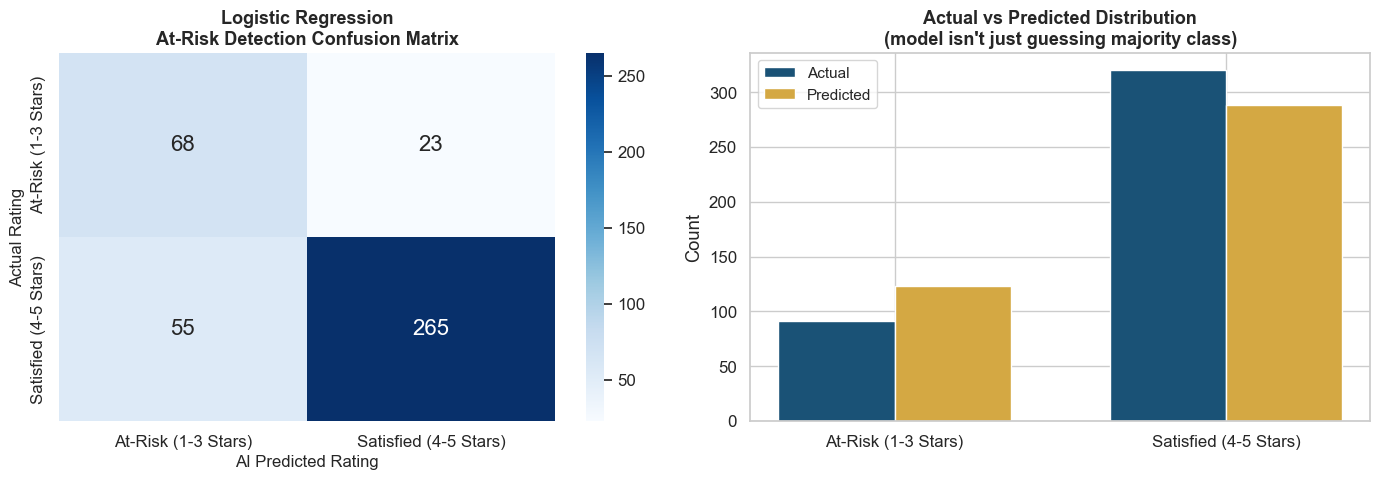

In [10]:
# detailed results + confusion matrix for best binary model
y_pred_b = binary_results[best_b_model]["predictions"]

print(f"DETAILED RESULTS: {best_b_model}")
print("=" * 60)
print(classification_report(y_test_b, y_pred_b, zero_division=0))

labels_b = ["At-Risk (1-3 Stars)", "Satisfied (4-5 Stars)"]
cm_b = confusion_matrix(y_test_b, y_pred_b, labels=labels_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues", xticklabels=labels_b,
            yticklabels=labels_b, ax=axes[0], annot_kws={"fontsize": 16})
axes[0].set_ylabel("Actual Rating", fontsize=12)
axes[0].set_xlabel("AI Predicted Rating", fontsize=12)
axes[0].set_title(f"{best_b_model}\nAt-Risk Detection Confusion Matrix", fontsize=13, fontweight="bold")

# prediction distribution comparison
actual_counts = pd.Series(y_test_b).value_counts()
pred_counts = pd.Series(y_pred_b).value_counts()
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, [actual_counts.get(l, 0) for l in labels_b], w, label="Actual", color=SHEA_BLUE)
axes[1].bar(x + w/2, [pred_counts.get(l, 0) for l in labels_b], w, label="Predicted", color=SHEA_GOLD)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_b)
axes[1].set_ylabel("Count")
axes[1].set_title("Actual vs Predicted Distribution\n(model isn't just guessing majority class)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Gradient Boosting is the most accurate with 84.1% accuracy and the highest Macro F1 (0.757). It catches 58% of at-risk customers from text alone, with 66% precision, meaning when it flags someone as at-risk, it is right 2 out of 3 times. Logistic Regression has better at-risk recall (72%) but more false positives (56% precision). Random Forest is the weakest here because it struggles with the minority class, only catching 43% of at-risk customers despite high overall accuracy. The tradeoff between recall and precision depends on the business use case: if missing an at-risk customer is costly, Logistic Regression's higher recall may be preferable.

## 5.2 Three-Class Prediction (Negative / Neutral / Positive)

This task is more challenging than the previous prediction. Instead of simply identifying satisfied versus at-risk customers, the model must now classify reviews into three groups: negative (1–2 stars), neutral (3 stars), and positive (4–5 stars).

This is significantly harder because 3-star reviews are inherently ambiguous. Customers in this group are often neither strongly satisfied nor strongly dissatisfied, and their language tends to reflect a mix of positive and negative comments.

In [13]:
# --- 3-CLASS MODEL ---
def rating_bucket(score):
    if score <= 2:
        return "Negative (1-2 Stars)"
    elif score == 3:
        return "Neutral (3 Stars)"
    else:
        return "Positive (4-5 Stars)"

df["rating_class"] = df["total_score"].apply(rating_bucket)

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    df[["review_text"] + extra_features],
    df["rating_class"],
    test_size=0.2,
    random_state=42,
    stratify=df["rating_class"],
)

tfidf_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english", token_pattern=TOKEN_PATTERN)
X_train_3h = build_hybrid_features(X_train_3["review_text"].astype(str), X_train_3[extra_features], tfidf_3, fit=True)
X_test_3h = build_hybrid_features(X_test_3["review_text"].astype(str), X_test_3[extra_features], tfidf_3, fit=False)

three_class_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
}

print("Training 3 models on the 3-class task...\n")
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'Neg Recall':<13} {'Neu Recall':<13} {'Pos Recall'}")
print("-" * 85)

three_results = {}
best_3_model = None
best_3_f1 = 0

for name, clf in three_class_models.items():
    clf.fit(X_train_3h, y_train_3)
    y_pred = clf.predict(X_test_3h)
    
    acc = accuracy_score(y_test_3, y_pred)
    f1 = f1_score(y_test_3, y_pred, average="macro")
    report = classification_report(y_test_3, y_pred, output_dict=True, zero_division=0)
    
    neg_r = report.get("Negative (1-2 Stars)", {}).get("recall", 0)
    neu_r = report.get("Neutral (3 Stars)", {}).get("recall", 0)
    pos_r = report.get("Positive (4-5 Stars)", {}).get("recall", 0)
    
    three_results[name] = {"accuracy": acc, "f1": f1, "predictions": y_pred}
    print(f"{name:<25} {acc:<12.1%} {f1:<12.3f} {neg_r:<13.0%} {neu_r:<13.0%} {pos_r:.0%}")
    
    if f1 > best_3_f1:
        best_3_f1 = f1
        best_3_model = name

print(f"\nBest 3-class model: {best_3_model} (Macro F1 = {best_3_f1:.3f})")

Training 3 models on the 3-class task...

Model                     Accuracy     Macro F1     Neg Recall    Neu Recall    Pos Recall
-------------------------------------------------------------------------------------
Logistic Regression       75.4%        0.558        58%           38%           83%
Random Forest             80.0%        0.404        11%           8%            100%
Gradient Boosting         80.5%        0.540        53%           13%           95%

Best 3-class model: Logistic Regression (Macro F1 = 0.558)



DETAILED RESULTS: Logistic Regression
                      precision    recall  f1-score   support

Negative (1-2 Stars)       0.36      0.58      0.44        38
   Neutral (3 Stars)       0.32      0.38      0.35        52
Positive (4-5 Stars)       0.93      0.83      0.88       321

            accuracy                           0.75       411
           macro avg       0.54      0.60      0.56       411
        weighted avg       0.80      0.75      0.77       411



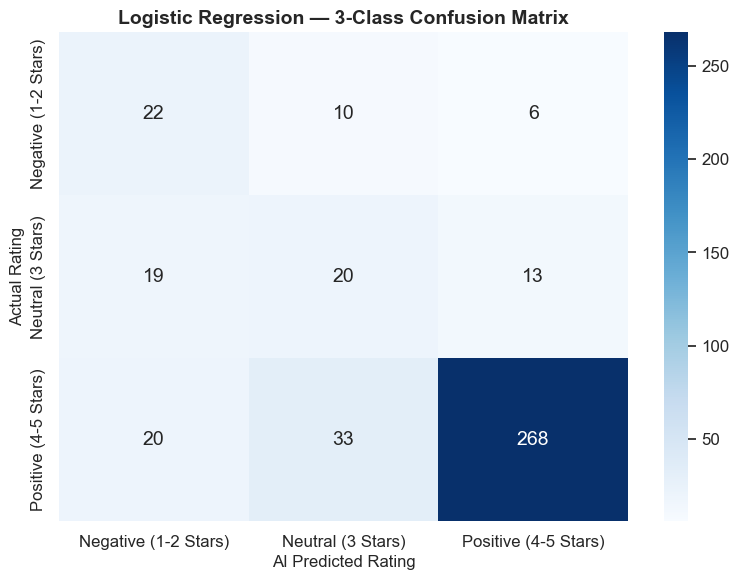

In [14]:
# 3-class confusion matrix
y_pred_3 = three_results[best_3_model]["predictions"]

print(f"\nDETAILED RESULTS: {best_3_model}")
print("=" * 60)
print(classification_report(y_test_3, y_pred_3, zero_division=0))

labels_3 = ["Negative (1-2 Stars)", "Neutral (3 Stars)", "Positive (4-5 Stars)"]
cm_3 = confusion_matrix(y_test_3, y_pred_3, labels=labels_3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt="d", cmap="Blues", xticklabels=labels_3,
            yticklabels=labels_3, ax=ax, annot_kws={"fontsize": 14})
ax.set_ylabel("Actual Rating", fontsize=12)
ax.set_xlabel("AI Predicted Rating", fontsize=12)
ax.set_title(f"{best_3_model} — 3-Class Confusion Matrix", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

These results show why overall accuracy alone is not sufficient for evaluating model performance. Gradient Boosting achieved the highest overall accuracy at 79.2%, but looking at the recall by class reveals important differences between the models. Random Forest performed poorly at identifying negative and neutral reviews, capturing only 3% of negative reviews and 2% of neutral reviews. In practice, it was largely predicting most reviews as positive and benefiting from the fact that positive reviews dominate the dataset. Logistic Regression provided the most balanced performance, correctly identifying 58% of negative reviews and 37% of neutral reviews, making it more useful for detecting dissatisfied customers. The key takeaway is that while predicting customer sentiment from text is feasible, neutral reviews remain the most difficult category to classify, since the language in 3-star reviews often contains a genuine mix of positive and negative signals.

## 5.3 Most Predictive Words by Category

When the prediction model evaluates a review, certain words influence its decision more than others. This section highlights the words that had the strongest impact on predicting each rating category. In simple terms, this analysis asks: which words most strongly signal that a review is negative, neutral, or positive? Longer bars indicate that a word had a stronger influence on the model’s prediction.

In [17]:
# what words are most predictive of each class?
lr_3 = three_class_models["Logistic Regression"]
feature_names = np.array(list(tfidf_3.get_feature_names_out()) + extra_features)

print("=" * 70)
print("MOST PREDICTIVE WORDS FOR EACH RATING CATEGORY")
print("These are the words/features that most strongly signal each class.")
print("=" * 70)

for i, label in enumerate(lr_3.classes_):
    top_idx = lr_3.coef_[i].argsort()[-12:][::-1]
    bottom_idx = lr_3.coef_[i].argsort()[:5]
    
    print(f"\n  {label}:")
    print(f"    {'Strongest positive signals:':<35}")
    for j in top_idx:
        word = feature_names[j]
        coef = lr_3.coef_[i][j]
        bar = "█" * int(abs(coef) * 4)
        print(f"      {word:<30} {bar} ({coef:+.3f})")

MOST PREDICTIVE WORDS FOR EACH RATING CATEGORY
These are the words/features that most strongly signal each class.

  Negative (1-2 Stars):
    Strongest positive signals:        
      don't                          ██████ (+1.627)
      workmanship average            █████ (+1.300)
      care                           ████ (+1.210)
      repairs                        ████ (+1.135)
      doesn't                        ████ (+1.125)
      bad                            ████ (+1.102)
      shea                           ████ (+1.059)
      months                         ████ (+1.058)
      outstanding experience         ████ (+1.036)
      buy shea                       ███ (+0.977)
      beware                         ███ (+0.969)
      things                         ███ (+0.945)

  Neutral (3 Stars):
    Strongest positive signals:        
      hoa                            █████ (+1.323)
      lovely home                    ████ (+1.065)
      unfortunately                  ████ (+

The predictive words tell a story that aligns with everything else in this analysis. Negative signals are concrete and specific: 'repairs,' 'months,' 'appliances,' 'workmanship average.' Neutral reviews use hedging language: 'unfortunately,' 'lacking,' 'nice home' (faint praise), and 'better' (implying something could be improved). Positive signals are emotional and relational: 'excellent,' 'professional,' 'helpful,' 'team,' 'awesome.' Note that 'vader' appears as the strongest positive predictor because the VADER sentiment score was included as a numeric feature, and it strongly correlates with positive ratings.